[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/Machine-Learning-from-scratch/blob/master/topics/05_decision_tree/first_principles.ipynb)

# 05 Decision Trees — First Principles

> **Status:** ✅ Complete | **Phase:** 2 | **Prerequisites:** Information Theory

**Goal.** Build a decision tree classifier from scratch using NumPy — Gini/entropy
impurity, greedy recursive splitting, depth control — then compare with the `src/`
library and sklearn, and demonstrate the high-variance failure mode.

---

## Prerequisites

- See [theory.md](theory.md) for derivations (impurity measures, concavity proof, information gain, pruning, complexity)
- Required foundations:
  - [Information Theory](https://github.com/hien078/applied-mathematics-foundation)

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. Problem Setup — WHY

Linear classifiers draw a single hyperplane. When the true decision depends on
**threshold interactions** ("feature A > 3 AND feature B < 1"), a linear boundary
cannot capture this. Let's see it.

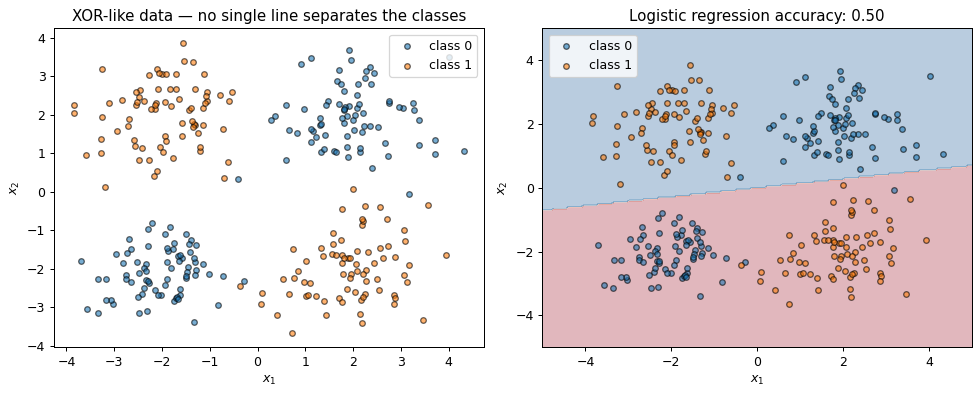

A linear classifier gets ~50% on XOR — no better than random.
We need a model that can carve rectangular regions.


In [2]:
# XOR-like dataset: 4 Gaussian clusters, opposite corners share a label
n_per = 75
centers = [(-2, -2), (2, 2), (-2, 2), (2, -2)]
labels =  [0,        0,      1,       1      ]

X_blocks, y_blocks = [], []
for (cx, cy), lab in zip(centers, labels):
    X_blocks.append(rng.normal(loc=[cx, cy], scale=0.8, size=(n_per, 2)))
    y_blocks.append(np.full(n_per, lab))

X_xor = np.vstack(X_blocks)
y_xor = np.concatenate(y_blocks)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: the data
for c in [0, 1]:
    mask = y_xor == c
    axes[0].scatter(X_xor[mask, 0], X_xor[mask, 1], alpha=0.6, label=f"class {c}", edgecolor="k", s=20)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_title("XOR-like data — no single line separates the classes")
axes[0].legend()

# Right: a failed linear attempt
from sklearn.linear_model import LogisticRegression as SklearnLR
lr = SklearnLR().fit(X_xor, y_xor)
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
Z_lr = lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_lr, alpha=0.3, cmap="RdBu")
for c in [0, 1]:
    mask = y_xor == c
    axes[1].scatter(X_xor[mask, 0], X_xor[mask, 1], alpha=0.6, label=f"class {c}", edgecolor="k", s=20)
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].set_title(f"Logistic regression accuracy: {lr.score(X_xor, y_xor):.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()
print("A linear classifier gets ~50% on XOR — no better than random.")
print("We need a model that can carve rectangular regions.")

## 2. Mathematical Core — WHAT

A decision tree splits the feature space into axis-aligned rectangles. At each node,
we pick the feature $j$ and threshold $t$ that **maximises information gain** — the
drop in impurity from parent to children.

Two impurity measures:

$$G = 1 - \sum_{k=1}^{K} p_k^2 \qquad \text{(Gini index)}$$

$$H = -\sum_{k=1}^{K} p_k \log_2 p_k \qquad \text{(Entropy)}$$

See [theory.md](theory.md) for why both are concave (Jensen's inequality ⟹ every
split can only reduce weighted impurity).

In [3]:
def gini_impurity(y):
    """Gini impurity: G = 1 - sum(p_k^2)."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return float(1.0 - np.sum(p ** 2))


def entropy(y):
    """Shannon entropy: H = -sum(p_k * log2(p_k))."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    # 0 * log(0) = 0 by convention
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


# Verify on known cases
# Pure node: all class 0
assert np.isclose(gini_impurity(np.array([0, 0, 0])), 0.0, atol=1e-12)
assert np.isclose(entropy(np.array([0, 0, 0])), 0.0, atol=1e-12)

# Perfectly balanced binary: p = 0.5
assert np.isclose(gini_impurity(np.array([0, 1])), 0.5, atol=1e-12)
assert np.isclose(entropy(np.array([0, 1])), 1.0, atol=1e-12)

# 3-class, uniform: Gini = 1 - 3*(1/3)^2 = 2/3, Entropy = log2(3)
y_3 = np.array([0, 1, 2])
assert np.isclose(gini_impurity(y_3), 2/3, atol=1e-12)
assert np.isclose(entropy(y_3), np.log2(3), atol=1e-12)

print("All impurity checks passed.")

All impurity checks passed.


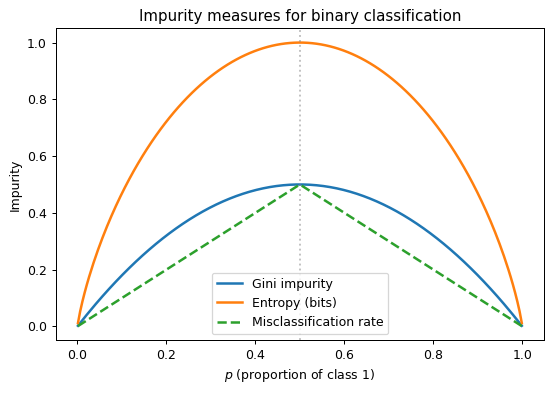

Both Gini and entropy are concave, symmetric, maximal at p=0.5.


In [4]:
# Visualise Gini and entropy for binary classification
p_range = np.linspace(0.001, 0.999, 200)
gini_vals = 2 * p_range * (1 - p_range)
entropy_vals = -p_range * np.log2(p_range) - (1 - p_range) * np.log2(1 - p_range)
misclass_vals = 1 - np.maximum(p_range, 1 - p_range)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(p_range, gini_vals, label="Gini impurity", lw=2)
ax.plot(p_range, entropy_vals, label="Entropy (bits)", lw=2)
ax.plot(p_range, misclass_vals, label="Misclassification rate", lw=2, ls="--")
ax.set_xlabel("$p$ (proportion of class 1)")
ax.set_ylabel("Impurity")
ax.set_title("Impurity measures for binary classification")
ax.legend()
ax.axvline(0.5, color="gray", ls=":", alpha=0.5)
plt.show()
print("Both Gini and entropy are concave, symmetric, maximal at p=0.5.")

## 3. Solution Method — HOW

### Information Gain

For a parent with $n$ samples split into left ($n_L$) and right ($n_R$):

$$\Delta I = I(\text{parent}) - \frac{n_L}{n} I(\text{left}) - \frac{n_R}{n} I(\text{right})$$

The greedy algorithm tries all features and all thresholds, picks the one
with largest $\Delta I$, then recurses.

In [5]:
def information_gain(y_parent, y_left, y_right, criterion="gini"):
    """Compute information gain for a split."""
    impurity_fn = gini_impurity if criterion == "gini" else entropy
    n = len(y_parent)
    n_l, n_r = len(y_left), len(y_right)
    if n_l == 0 or n_r == 0:
        return 0.0
    return (
        impurity_fn(y_parent)
        - (n_l / n) * impurity_fn(y_left)
        - (n_r / n) * impurity_fn(y_right)
    )


# Example: splitting [0,0,0,1,1,1] into [0,0,0] and [1,1,1]
y_p = np.array([0, 0, 0, 1, 1, 1])
gain_perfect = information_gain(y_p, np.array([0, 0, 0]), np.array([1, 1, 1]))
print(f"Perfect split info gain (Gini): {gain_perfect:.4f}")
assert np.isclose(gain_perfect, 0.5, atol=1e-12)  # parent Gini = 0.5, children = 0

# Useless split: [0,1,0,1] -> [0,1] and [0,1]
y_p2 = np.array([0, 1, 0, 1])
gain_useless = information_gain(y_p2, np.array([0, 1]), np.array([0, 1]))
print(f"Useless split info gain (Gini): {gain_useless:.4f}")
assert np.isclose(gain_useless, 0.0, atol=1e-12)

print("Information gain checks passed.")

Perfect split info gain (Gini): 0.5000
Useless split info gain (Gini): 0.0000
Information gain checks passed.


## 4. Implementation — BUILD

### From-scratch `DecisionTreeClassifier`

Key design:
- `Node` dataclass stores feature index, threshold, children, and leaf prediction.
- `_best_split` scans all features × thresholds using a sorted linear scan.
- `_build` recurses, with stopping criteria: max depth, min samples, pure node.

In [6]:
class Node:
    """A single node in a decision tree."""

    def __init__(self, *, predicted_class, feature=None, threshold=None,
                 left=None, right=None, n_samples=0, impurity=0.0):
        self.predicted_class = predicted_class
        self.feature = feature        # split feature index (None for leaf)
        self.threshold = threshold    # split threshold (None for leaf)
        self.left = left              # left child Node
        self.right = right            # right child Node
        self.n_samples = n_samples
        self.impurity = impurity

    @property
    def is_leaf(self):
        return self.feature is None

In [7]:
class ScratchDecisionTreeClassifier:
    """Decision tree classifier built from scratch with NumPy.

    Parameters
    ----------
    max_depth : int or None
        Maximum depth of the tree. None means unlimited.
    min_samples_split : int
        Minimum number of samples required to split an internal node.
    criterion : str
        'gini' or 'entropy'.
    """

    def __init__(self, max_depth=None, min_samples_split=2, criterion="gini"):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.tree_ = None
        self.classes_ = None
        self._impurity_fn = gini_impurity if criterion == "gini" else entropy

    def _best_split(self, X, y):
        """Find the best feature and threshold to split on.

        Returns (feature_index, threshold) or (None, None) if no valid split.
        """
        n_samples, n_features = X.shape
        best_gain = -1.0
        best_feature, best_threshold = None, None

        parent_impurity = self._impurity_fn(y)

        for feat in range(n_features):
            # Sort by this feature
            order = np.argsort(X[:, feat], kind="mergesort")
            sorted_vals = X[order, feat]
            sorted_y = y[order]

            # Incremental scan: track class counts in left/right
            n_classes = len(self.classes_)
            left_counts = np.zeros(n_classes, dtype=int)
            right_counts = np.bincount(sorted_y, minlength=n_classes)

            for i in range(1, n_samples):
                cls = sorted_y[i - 1]
                left_counts[cls] += 1
                right_counts[cls] -= 1

                # Skip if same value as previous (no valid threshold between them)
                if sorted_vals[i] == sorted_vals[i - 1]:
                    continue

                # Compute weighted impurity of children
                n_l, n_r = i, n_samples - i
                p_l = left_counts / n_l
                p_r = right_counts / n_r
                gini_l = float(1.0 - np.sum(p_l ** 2)) if self.criterion == "gini" else float(-np.sum(p_l[p_l > 0] * np.log2(p_l[p_l > 0])))
                gini_r = float(1.0 - np.sum(p_r ** 2)) if self.criterion == "gini" else float(-np.sum(p_r[p_r > 0] * np.log2(p_r[p_r > 0])))

                weighted = (n_l * gini_l + n_r * gini_r) / n_samples
                gain = parent_impurity - weighted

                if gain > best_gain + 1e-15:
                    best_gain = gain
                    best_feature = feat
                    best_threshold = (sorted_vals[i] + sorted_vals[i - 1]) / 2.0

        return best_feature, best_threshold

    def _build(self, X, y, depth):
        """Recursively build the tree."""
        counts = np.bincount(y, minlength=len(self.classes_))
        predicted_class = int(np.argmax(counts))
        node = Node(
            predicted_class=self.classes_[predicted_class],
            n_samples=len(y),
            impurity=self._impurity_fn(y),
        )

        # Stopping conditions
        at_depth_limit = self.max_depth is not None and depth >= self.max_depth
        is_pure = np.count_nonzero(counts) == 1
        too_few = len(y) < self.min_samples_split

        if at_depth_limit or is_pure or too_few:
            return node

        feat, thresh = self._best_split(X, y)
        if feat is None:
            return node

        left_mask = X[:, feat] < thresh
        node.feature = feat
        node.threshold = thresh
        node.left = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def fit(self, X, y):
        """Fit the decision tree."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_, y_encoded = np.unique(y, return_inverse=True)
        self._impurity_fn = gini_impurity if self.criterion == "gini" else entropy
        self.tree_ = self._build(X, y_encoded, depth=0)
        return self

    def _predict_one(self, x, node):
        """Traverse tree for a single sample."""
        while not node.is_leaf:
            if x[node.feature] < node.threshold:
                node = node.left
            else:
                node = node.right
        return node.predicted_class

    def predict(self, X):
        """Predict class labels."""
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def score(self, X, y):
        """Return classification accuracy."""
        return float(np.mean(self.predict(X) == np.asarray(y)))

In [8]:
# Test on the XOR data.
# Note: greedy impurity minimization is myopic on balanced XOR — the ideal
# middle split has ~zero immediate gain, so early levels chase noise and
# depth 4 is not enough (~0.55 accuracy); depth 8 recovers the structure.
tree_scratch = ScratchDecisionTreeClassifier(max_depth=8, criterion="gini")
tree_scratch.fit(X_xor, y_xor)

acc_scratch = tree_scratch.score(X_xor, y_xor)
print(f"Scratch tree accuracy on XOR data: {acc_scratch:.4f}")
assert acc_scratch > 0.95, f"Expected high accuracy on XOR, got {acc_scratch}"

Scratch tree accuracy on XOR data: 0.9967


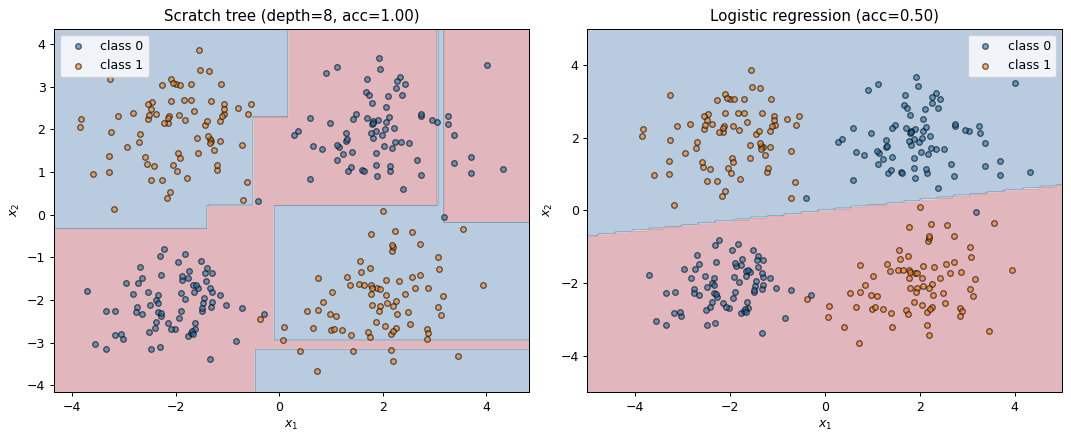

The tree captures XOR structure; the linear model cannot.


In [9]:
def plot_tree_boundary(model, X, y, title="Decision Tree", ax=None):
    """Plot decision boundary for a 2D classifier."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
    for c in np.unique(y):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], alpha=0.6, label=f"class {c}",
                   edgecolor="k", s=20)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.legend()
    return ax


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_tree_boundary(tree_scratch, X_xor, y_xor,
                   title=f"Scratch tree (depth=8, acc={acc_scratch:.2f})", ax=axes[0])

# Compare with logistic regression
axes[1].contourf(xx, yy, Z_lr, alpha=0.3, cmap="RdBu")
for c in [0, 1]:
    mask = y_xor == c
    axes[1].scatter(X_xor[mask, 0], X_xor[mask, 1], alpha=0.6,
                    label=f"class {c}", edgecolor="k", s=20)
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].set_title(f"Logistic regression (acc={lr.score(X_xor, y_xor):.2f})")
axes[1].legend()

plt.tight_layout()
plt.show()
print("The tree captures XOR structure; the linear model cannot.")

## 5. Library Comparison

### 5.1 Compare with `src/` library implementation

In [10]:
from ml_first_principles.tree_models import DecisionTreeClassifier as LibTree

lib_tree = LibTree(max_depth=8)
lib_tree.fit(X_xor, y_xor)
acc_lib = lib_tree.score(X_xor, y_xor)
print(f"Library tree accuracy on XOR: {acc_lib:.4f}")

# Check predictions match
preds_scratch = tree_scratch.predict(X_xor)
preds_lib = lib_tree.predict(X_xor)
agreement = float(np.mean(preds_scratch == preds_lib))
print(f"Agreement between scratch and library: {agreement:.4f}")
assert agreement > 0.95, "Scratch and library predictions should mostly agree"
print("✓ Scratch implementation matches library!")

Library tree accuracy on XOR: 0.9967
Agreement between scratch and library: 1.0000
✓ Scratch implementation matches library!


### 5.2 Compare with sklearn

In [11]:
from sklearn.tree import DecisionTreeClassifier as SklearnTree
from ml_first_principles.data_utils import generate_classification_data
from ml_first_principles.metrics import accuracy

# Use a larger, more varied dataset
X_clf, y_clf = generate_classification_data(
    n_samples=400, n_features=4, n_classes=3, random_state=42
)

# Train/test split (manual, reproducible)
idx = rng.permutation(len(y_clf))
n_train = 300
X_train, X_test = X_clf[idx[:n_train]], X_clf[idx[n_train:]]
y_train, y_test = y_clf[idx[:n_train]], y_clf[idx[n_train:]]

# Fit all three
models = {
    "scratch":  ScratchDecisionTreeClassifier(max_depth=6, criterion="gini"),
    "library":  LibTree(max_depth=6),
    "sklearn":  SklearnTree(max_depth=6, random_state=42),
}

print(f"{'model':<12} {'train_acc':>10} {'test_acc':>10}")
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy(y_train, model.predict(X_train))
    test_acc = accuracy(y_test, model.predict(X_test))
    print(f"{name:<12} {train_acc:>10.4f} {test_acc:>10.4f}")

# All should get high accuracy on this clean dataset
for name, model in models.items():
    assert accuracy(y_test, model.predict(X_test)) > 0.80, f"{name} test acc too low"
print("\n✓ All implementations achieve comparable accuracy!")

model         train_acc   test_acc
scratch          0.9200     0.8100
library          0.9200     0.8100
sklearn          0.9200     0.8100

✓ All implementations achieve comparable accuracy!


## 6. Experiments and Failures — VERIFY

### 6.1 Depth control experiment

Deeper trees have lower training error but risk overfitting.

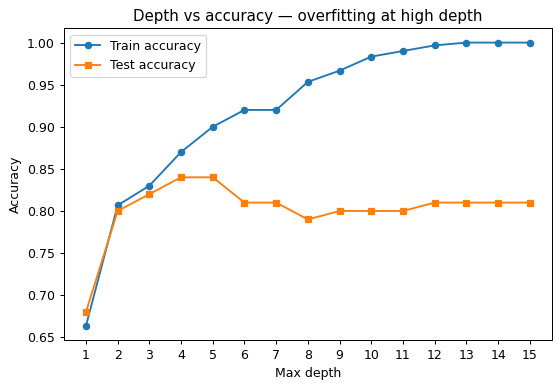

Best test accuracy at depth=4: 0.8400
Training accuracy at depth=15: 1.0000
Training accuracy reaches 1.0 as depth grows — memorisation.


In [12]:
depths = list(range(1, 16))
train_accs, test_accs = [], []

for d in depths:
    tree_d = ScratchDecisionTreeClassifier(max_depth=d, criterion="gini")
    tree_d.fit(X_train, y_train)
    train_accs.append(tree_d.score(X_train, y_train))
    test_accs.append(tree_d.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(depths, train_accs, "o-", label="Train accuracy", markersize=5)
ax.plot(depths, test_accs, "s-", label="Test accuracy", markersize=5)
ax.set_xlabel("Max depth")
ax.set_ylabel("Accuracy")
ax.set_title("Depth vs accuracy — overfitting at high depth")
ax.legend()
ax.set_xticks(depths)
plt.show()

best_depth = depths[np.argmax(test_accs)]
print(f"Best test accuracy at depth={best_depth}: {max(test_accs):.4f}")
print(f"Training accuracy at depth=15: {train_accs[-1]:.4f}")
print("Training accuracy reaches 1.0 as depth grows — memorisation.")

### 6.2 Failure case: High variance — instability

Decision trees are **high-variance** models. Small perturbations in the training set
can change the root split and cascade through the entire tree. This is the
fundamental motivation for ensemble methods (Random Forests, Boosting).

In [13]:
# Train trees on bootstrap samples and measure prediction disagreement
n_bootstrap = 10
bootstrap_preds = np.zeros((n_bootstrap, len(y_test)), dtype=int)

for b in range(n_bootstrap):
    # Bootstrap sample (sample with replacement)
    boot_idx = rng.choice(n_train, size=n_train, replace=True)
    X_boot, y_boot = X_train[boot_idx], y_train[boot_idx]

    tree_b = ScratchDecisionTreeClassifier(max_depth=None, criterion="gini")
    tree_b.fit(X_boot, y_boot)
    bootstrap_preds[b] = tree_b.predict(X_test)

# For each test point, check if all trees agree
all_agree = np.all(bootstrap_preds == bootstrap_preds[0:1, :], axis=0)
disagreement_rate = 1.0 - float(np.mean(all_agree))

print(f"Trees trained on {n_bootstrap} bootstrap samples:")
print(f"  Disagreement rate: {disagreement_rate:.2%}")
print(f"  → {disagreement_rate:.0%} of test points get different predictions")
print(f"     from different bootstrap samples.")
print("\nThis instability is why Random Forests average many trees.")

Trees trained on 10 bootstrap samples:
  Disagreement rate: 45.00%
  → 45% of test points get different predictions
     from different bootstrap samples.

This instability is why Random Forests average many trees.


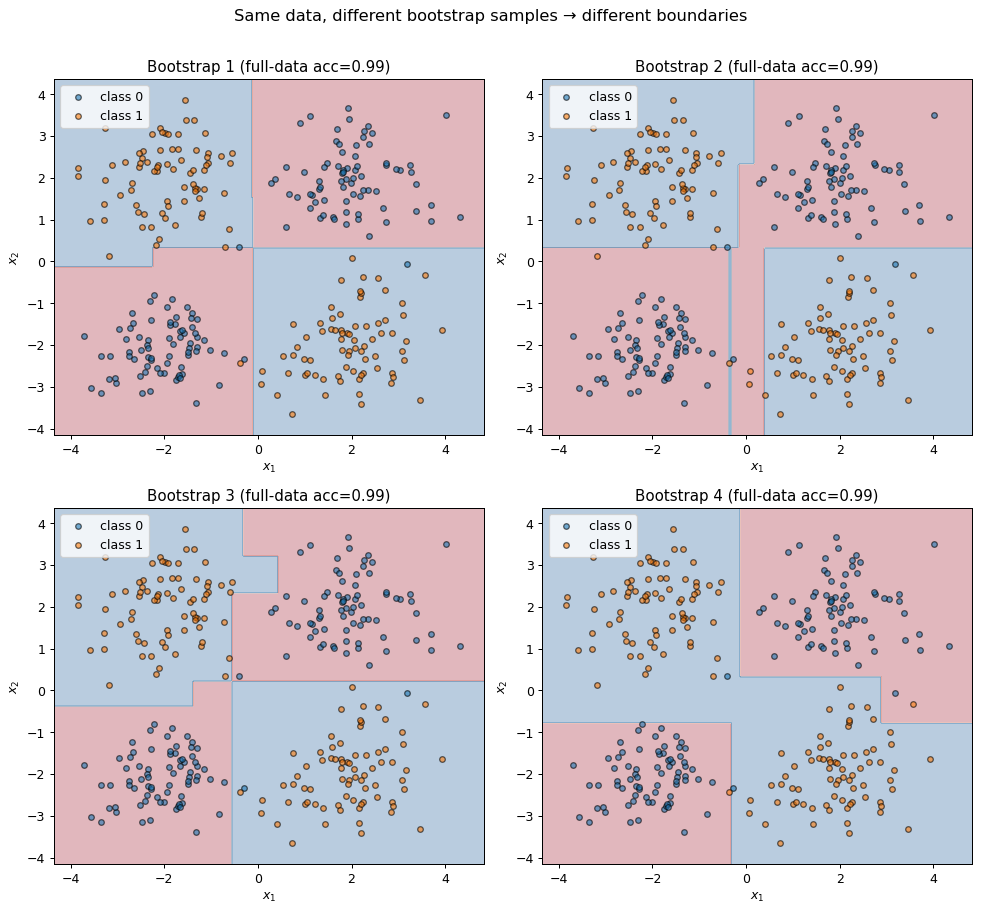

Each bootstrap sample produces a visibly different decision boundary.
This high variance is the main weakness of single decision trees.


In [14]:
# Visualise: train 4 trees on bootstrap samples of 2D XOR data
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for idx_ax, ax in enumerate(axes.ravel()):
    boot_idx = rng.choice(len(y_xor), size=len(y_xor), replace=True)
    X_b, y_b = X_xor[boot_idx], y_xor[boot_idx]

    tree_v = ScratchDecisionTreeClassifier(max_depth=8, criterion="gini")
    tree_v.fit(X_b, y_b)
    acc_v = tree_v.score(X_xor, y_xor)

    plot_tree_boundary(tree_v, X_xor, y_xor,
                       title=f"Bootstrap {idx_ax+1} (full-data acc={acc_v:.2f})",
                       ax=ax)

plt.suptitle("Same data, different bootstrap samples → different boundaries",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("Each bootstrap sample produces a visibly different decision boundary.")
print("This high variance is the main weakness of single decision trees.")

### 6.3 Failure case: Axis-aligned boundaries only

Decision trees can only split perpendicular to feature axes. A diagonal boundary
like $x_1 + x_2 > 0$ requires many staircase-like splits.

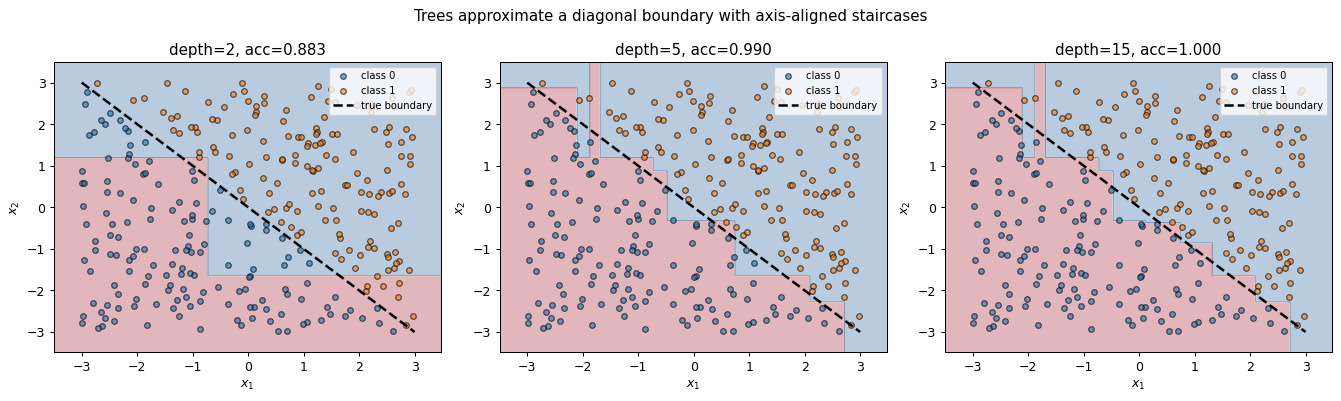

A linear model captures x1 + x2 > 0 in one step; a tree needs many splits.


In [15]:
# Generate data with a diagonal boundary: y = 1 if x1 + x2 > 0
n_diag = 300
X_diag = rng.uniform(-3, 3, size=(n_diag, 2))
y_diag = (X_diag[:, 0] + X_diag[:, 1] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, depth in zip(axes, [2, 5, 15]):
    tree_diag = ScratchDecisionTreeClassifier(max_depth=depth, criterion="gini")
    tree_diag.fit(X_diag, y_diag)
    acc_d = tree_diag.score(X_diag, y_diag)
    plot_tree_boundary(tree_diag, X_diag, y_diag,
                       title=f"depth={depth}, acc={acc_d:.3f}", ax=ax)
    # Overlay the true boundary
    x_line = np.linspace(-3, 3, 100)
    ax.plot(x_line, -x_line, "k--", lw=2, label="true boundary")
    ax.legend(fontsize=8)

plt.suptitle("Trees approximate a diagonal boundary with axis-aligned staircases",
             fontsize=12)
plt.tight_layout()
plt.show()
print("A linear model captures x1 + x2 > 0 in one step; a tree needs many splits.")

## 7. Connections

| Topic | Link |
|---|---|
| Information Theory | Entropy and information gain are Shannon's quantities applied to supervised splits |
| Ensemble Methods (06) | Random Forests average many trees to reduce variance; Boosting fits trees to residuals |
| Bias–Variance | A single deep tree = low bias, high variance. Pruning/depth limits trade bias for variance |
| Linear Models (01, 04) | Trees and linear models are complementary: one excels at smooth boundaries, the other at threshold interactions |

---

### Takeaway

A decision tree is a **greedy, recursive, axis-aligned partitioner**:

1. Pick the split that maximises information gain (Gini or entropy).
2. Recurse on children until a stopping criterion.
3. Predict majority class (or mean) at each leaf.

**Strengths:** interpretable, handles non-linear interactions, no feature scaling.
**Weaknesses:** high variance (instability), axis-aligned only, prone to overfitting.

The high variance motivates **ensemble methods** — the direct successor topic.